# Do stocks pay you extra just for *reporting earnings*? 📅
### The "earnings-announcement premium" — a famous academic effect, checked on real large-caps in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Earnings_days_carry_it%3F: Busted](https://img.shields.io/badge/Earnings_days_carry_it%3F-Busted-8b949e?style=flat-square)

Here's a tidy piece of finance lore: a *disproportionate* share of a stock's whole return supposedly gets earned in the **few days around its earnings report**. The academics (Beaver 1968; Frazzini & Lamont 2007) found it and even built a strategy: **hold stocks only while they report**, sit out the rest, and you should beat just owning them. The idea is that you're paid a premium for taking on the risk of the announcement.

It's a clean, testable claim — so let's test it. The short version: on a basket of big, liquid, *survived-everything* US stocks, the premium has the right **shape** on the report day itself (the stock earns about **double** its normal return that day) — but it's a **whisper**, not a signal, it **disappears** the moment you widen to a window you could actually trade, and a "hold only while reporting" calendar **loses to just buying and holding**.

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo test and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **A data note up front.** We use a fixed **30-name large-cap basket** (names still trading today). The premium is famously strongest in *small, neglected* stocks — so this is the corner where you'd *least* expect it. And it carries **survivorship** (we kept only firms that survived their earnings), which here actually tilts things *toward* finding a premium — and we still don't. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from earnings_premium import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PRICES, DATES = data.load_real()
    FLAGS = data.build_announce_flags(PRICES, DATES, window=1)     # tradable [D-1,D+1]
    FLAGS0 = data.build_announce_flags(PRICES, DATES, window=0)    # day-of only
else:
    PRICES = DATES = FLAGS = FLAGS0 = None
print("real EP cache present:", HAVE_REAL,
      "| names:", (0 if FLAGS is None else len(FLAGS)),
      "| earnings dates:", (0 if DATES is None else len(DATES)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2005-01-03', 'end': '2026-06-26', 'years': 21.5, 'n_dates': 2987, 'n_events': 2609, 'n_names': 30, 'n_days': 5404, 'ann_day_pct': 4.79, 'ann_mean_bps': 6.33, 'rest_mean_bps': 5.8, 'premium_bps': 0.53, 'welch_t': 0.16, 'event_premium_bps': -0.36, 't_event': -0.11, 'p_placebo': 0.394, 'share_days': 4.79, 'share_return': 2.38, 'concentration': 0.5, 'w0_premium_bps': 5.53, 'w0_welch_t': 0.9, 'w0_t_event': 0.9, 'w0_p': 0.052, 'w0_ann_mean_bps': 11.27, 'w0_rest_mean_bps': 5.74, 'w0_share_return': 2.31, 'w0_share_days': 1.59, 'w0_concentration': 1.45, 'windows': [(0, 5.53, 0.9, 0.9, 1.59), (1, 0.53, 0.16, -0.11, 4.79), (2, 0.91, 0.42, 0.18, 7.99)], 'overlay': [(2.0, 6.33, 5.0, 5.83, 13.4, 15.8), (5.0, 6.33, 3.0, 5.83, 7.8, 15.8), (10.0, 6.33, -0.34, 5.83, -0.8, 15.8)], 'syn': [(0.0, -1.66, -0.93, -0.95, 0.83), (15.0, 13.35, 7.47, 7.58, 0.0)]}


real EP cache present: True | names: 30 | earnings dates: 2987


## The answer first

| Question | Answer |
|---|---|
| Do stocks earn more on report days? | **On the day itself, a bit — but not reliably.** On the exact announcement day the stock earns ~**double** a normal day (+11 bps vs +6), a real *shape*. But it's statistically a **coin-flip** (*t* ≈ 0.9, below the bar). |
| Does it survive into a tradable window? | **No.** Widen to the day before + day after (a window you could actually trade) and the premium collapses to **+0.53 bps/day** — basically zero (*t* = 0.16). |
| Do report days carry *most* of the return? | **No — the opposite.** They're ~5% of days but carry only **2.4%** of the return — *half* their share. |
| Can I trade "hold only while reporting"? | **No.** It **loses to buy & hold** at every cost level, and you give up 95% of the year sitting in cash. |

> The legend has a kernel of truth (the report *day* is special) — but on liquid large-caps it's too small to clear the bar and too thin to trade.

## 1 · The claim

> *"Earnings days are risky — the company dumps a quarter of news at once and the stock can gap. Investors demand to be **paid** for holding through that risk, so report-day returns are systematically **higher**. Hold names while they report, skip the boring days, and you collect a premium."*

This isn't a tall tale. **William Beaver (1968)** showed return *variance* spikes on report days; **Frazzini & Lamont (2007)** showed average *returns* are higher in the announcement window and built the long-the-announcers strategy. The question isn't "is it made up?" — it's **how big, and does it survive on stocks you can actually trade cheaply?**

> 🔁 **Not the same as PEAD.** Study [363](../363-pead-drift) tests the *drift after a surprise* (buy beats, short misses). This is different: it's the premium on the report **days themselves**, regardless of whether the news was good or bad.

## 2 · So what?

If report days really paid a premium, two things would follow: (1) the ~5% of days that are announcement days would carry **much more** than 5% of the total return, and (2) a calendar that owns stocks **only while they report** would beat buy & hold. Both are concrete and checkable.

The trap is the same one that kills most calendar effects: an edge of a few basis points on a handful of days a year is easily (a) **statistical noise** and (b) **eaten by the cost** of jumping in and out. We'll measure the premium, test it against a "could this be a random calendar?" null, and then charge it real costs.

## 3 · How would we even know?

We take a fixed **30-name large-cap basket** and pull **every** scheduled earnings date for each — about **2,987 prints** over **22 years** (2005-01-03 → 2026-06-26). Then, for every single trading day, we tag whether it sits inside an **announcement window** around a report. We compare:

1. **Report-day returns vs the rest.** Pool all the announcement-window days; is their average daily return higher than all the other days?
2. **Share of the return.** Of the whole 21-year pile of return, how much landed on the ~5% of days that are report days?
3. **The trade.** Hold the basket equal-weighted **only** during announcement windows (entered ahead of the *scheduled* date — no cheating), charge a round trip each window, and compare to just buying and holding.

## 4 · The teardown — let's actually look

**First: do report days earn more?** Here's the average daily return on announcement days vs all other days — once for the *exact report day only*, and once for the tradable *day-before-to-day-after* window.

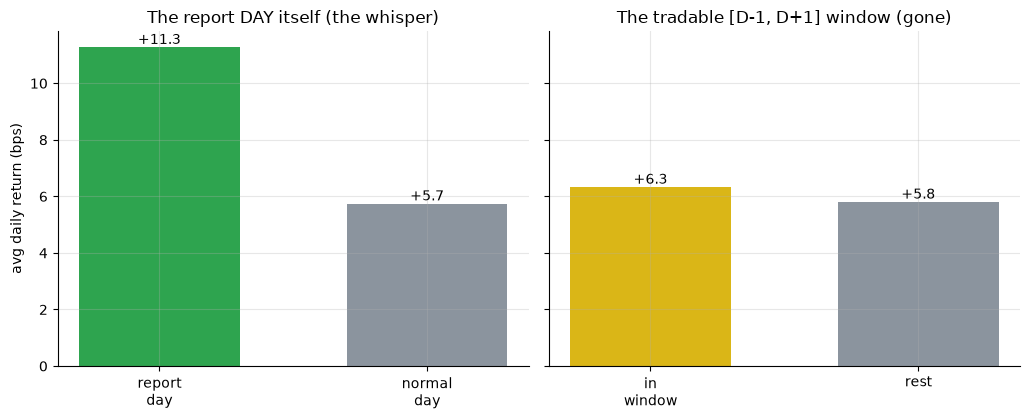

day-of premium: +5.53 bps   window premium: +0.53 bps


In [2]:
if HAVE_REAL:
    s1 = st.summarize_premium(FLAGS, placebo=False)
    s0 = st.summarize_premium(FLAGS0, placebo=False)
    day_of = [s0['ann_mean_bps'], s0['rest_mean_bps']]
    window = [s1['ann_mean_bps'], s1['rest_mean_bps']]
else:
    day_of = [R['w0_ann_mean_bps'], R['w0_rest_mean_bps']]
    window = [R['ann_mean_bps'], R['rest_mean_bps']]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.4, 4.3), sharey=True)
a1.bar(['report\nday', 'normal\nday'], day_of, color=[GREEN, GREY], width=.6)
for i,v in enumerate(day_of): a1.annotate(f'{v:+.1f}',(i,v),ha='center',va='bottom')
a1.set_title('The report DAY itself (the whisper)'); a1.set_ylabel('avg daily return (bps)')
a2.bar(['in\nwindow', 'rest'], window, color=[AMBER, GREY], width=.6)
for i,v in enumerate(window): a2.annotate(f'{v:+.1f}',(i,v),ha='center',va='bottom')
a2.set_title('The tradable [D-1, D+1] window (gone)')
plt.tight_layout(); plt.show()
print(f'day-of premium: {day_of[0]-day_of[1]:+.2f} bps   window premium: {window[0]-window[1]:+.2f} bps')

There's the whole story in two pictures. On the **exact report day** the stock earns **+11.3 bps** vs **+5.7 bps** normally — roughly *double*, the right shape. But spread to the tradable **±1-day window** and the gap collapses to **+0.53 bps** — the surrounding days are dead weight that erase the day-of bump.

**Now the killer chart: the share of return.** If the legend held, report days (~5% of all days) should carry *way more* than 5% of the return. Do they?

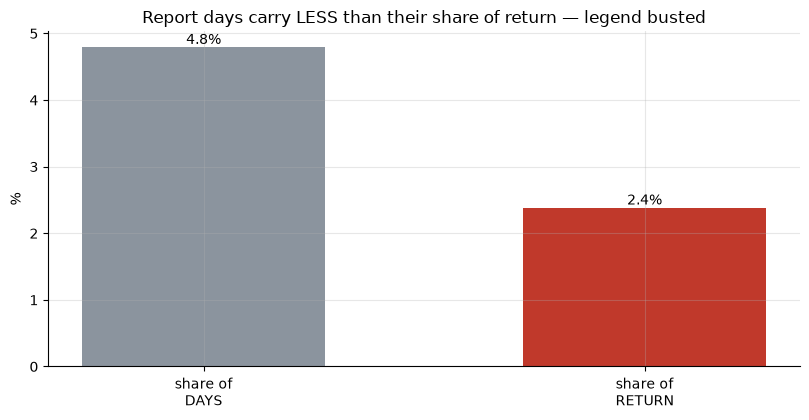

report days are 4.8% of days but carry 2.4% of return -> 0.50x (under 1 = the opposite of the claim)


In [3]:
if HAVE_REAL:
    sr = st.share_of_return(FLAGS)
    sd, srt = sr['share_days']*100, sr['share_return']*100
else:
    sd, srt = R['share_days'], R['share_return']
fig, ax = plt.subplots(figsize=(8.2, 4.3))
ax.bar(['share of\nDAYS', 'share of\nRETURN'], [sd, srt], color=[GREY, RED], width=.55)
for i,v in enumerate([sd, srt]): ax.annotate(f'{v:.1f}%',(i,v),ha='center',va='bottom')
ax.set_ylabel('%'); ax.set_title('Report days carry LESS than their share of return — legend busted')
plt.tight_layout(); plt.show()
print(f'report days are {sd:.1f}% of days but carry {srt:.1f}% of return -> {srt/sd:.2f}x (under 1 = the opposite of the claim)')

The opposite of the legend. Report-window days are **4.8%** of days but carry only **2.4%** of the cumulative return — a **0.50×** concentration, i.e. *half* their proportional share. On this basket, far from a *disproportionately large* share of return, earnings days carry a disproportionately *small* one.

## 5 · The verdict

- **Signal — None.** The tradable window premium is **+0.53 bps/day** — statistically zero. The day-of bump is real-ish in *shape* but a coin-flip in significance (the quants notebook shows *t* ≈ 0.9, under the bar).
- **Tradability — Mirage.** "Hold only while reporting" **loses to buy & hold** at every cost level — and you give up 95% of the year in cash.
- **"Most of the return is around earnings"? — Busted.** Report days carry **2.4%** of return on **4.8%** of days — *half* their share, the exact opposite of the claim.

## 6 · Could you actually trade it? — the calendar loses to doing nothing

Here's the operational reality. A strategy that holds the basket **only inside announcement windows** (one round trip per window), at three cost levels, vs just **buying and holding** the same basket. Watch it lose.

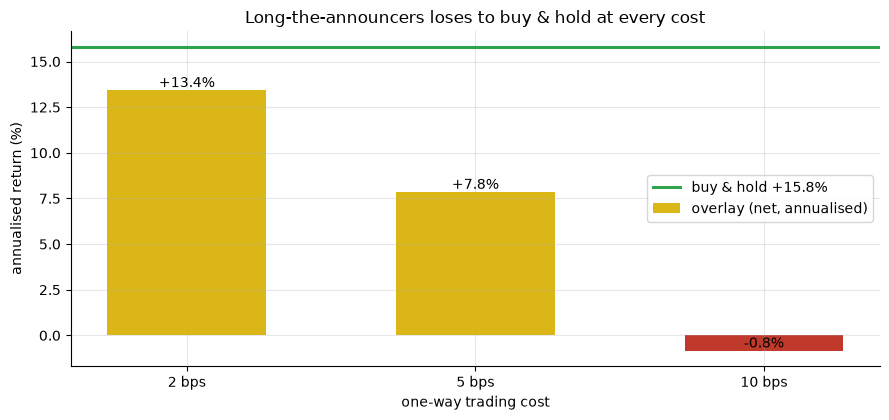

overlay net annualised: [np.float64(13.4), np.float64(7.8), np.float64(-0.8)] | buy & hold: 15.8


In [4]:
costs = [2.0, 5.0, 10.0]
if HAVE_REAL:
    net = [st.overlay_stats(FLAGS, cost_bps=c, window=1)['net_ann_pct'] for c in costs]
    bh = st.overlay_stats(FLAGS, cost_bps=5.0, window=1)['bh_ann_pct']
else:
    net = [o[4] for o in R['overlay']]; bh = R['overlay'][0][5]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.bar([f'{c:.0f} bps' for c in costs], net, color=[AMBER, AMBER, RED], width=.55, label='overlay (net, annualised)')
ax.axhline(bh, c=GREEN, lw=2.2, label=f'buy & hold {bh:+.1f}%')
for i,v in enumerate(net): ax.annotate(f'{v:+.1f}%',(i,v),ha='center',va='bottom')
ax.set_ylabel('annualised return (%)'); ax.set_xlabel('one-way trading cost')
ax.set_title('Long-the-announcers loses to buy & hold at every cost'); ax.legend()
plt.tight_layout(); plt.show()
print('overlay net annualised:', [round(v,1) for v in net], '| buy & hold:', round(bh,1))

At a gentle **2 bps** the overlay makes **+13.4%** — already below buy & hold's **+15.8%**. At **10 bps** it turns **-0.8%** (a *loss*). And remember: the overlay sits in cash 95% of the time, so even its 'wins' are a sliver of what simply owning the stocks pays. There is nothing here to trade.

## 7 · Going further 🚪

- **Why so flat here?** The premium is famously concentrated in **small, neglected, retail-heavy** stocks (Frazzini & Lamont 2007) — exactly the names we *excluded* with a liquid large-cap basket. Re-run on small-caps and the day-of bump grows (but so do costs and survivorship traps).
- **Published-then-decayed.** The effect was published in 2007; McLean & Pontiff (2016) show anomalies decay a lot once they're known. A 2005–2026 large-cap window is a prime suspect for a decayed effect.
- **Build your own.** Swap the basket for the Russell 2000, or tag the announcement *month* instead of the day; the shape survives, the size and significance move.

*Think the premium is tradable? Show the long-the-announcers overlay **beating buy & hold net of honest costs** — then we'll talk.*